# Regularization in Deep Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X , y  = make_moons(100 , noise = 0.25 , random_state = 2)

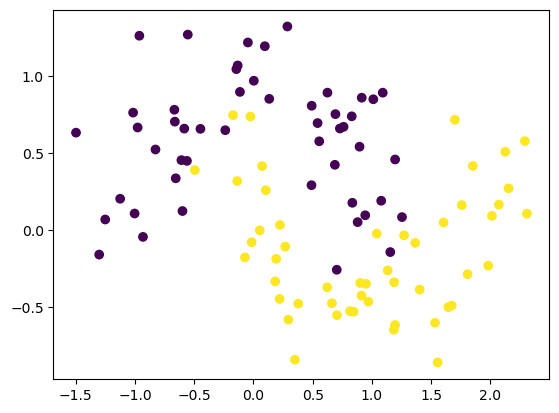

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0] , X[:,1], c = y)
plt.show()

In [4]:
model1 = Sequential()
model1.add(Dense(128, input_dim = 2 , activation = "relu"))
model1.add(Dense(128,  activation = "relu"))
model1.add(Dense(1, activation = "sigmoid"))

model1.summary()

C:\Users\himan\anaconda3\envs\dl\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate = 0.01)
model1.compile(loss = 'binary_crossentropy' , optimizer = adam , metrics = ['accuracy'])

history1 = model1.fit(X , y , epochs = 2000 , validation_split = 0.2 , verbose = False)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 755us/step


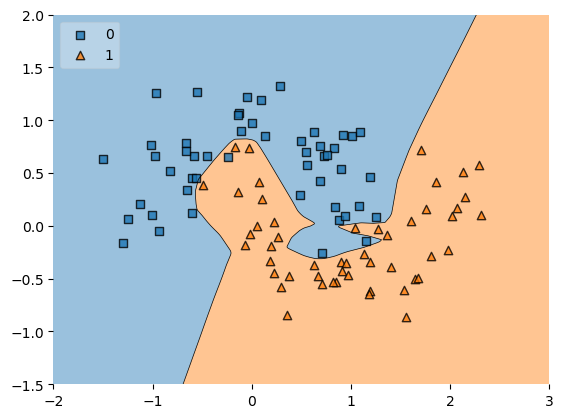

In [7]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

From the above plot overfitting is clearly shown

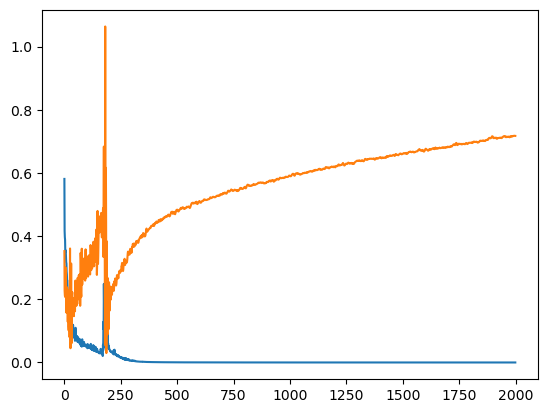

In [8]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

From the above graph there is huge gap in the training error and testing error .

# Now adding a regulrization in our model and see 

In [9]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 671us/step


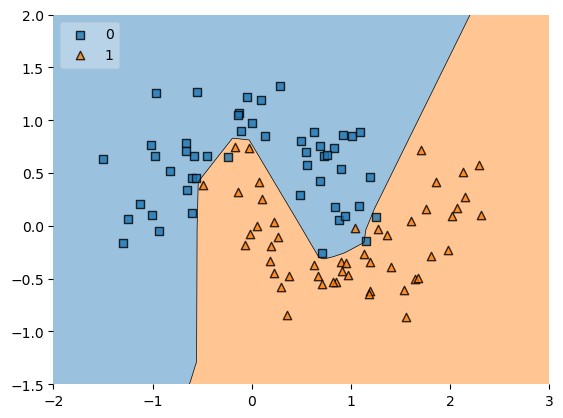

In [11]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

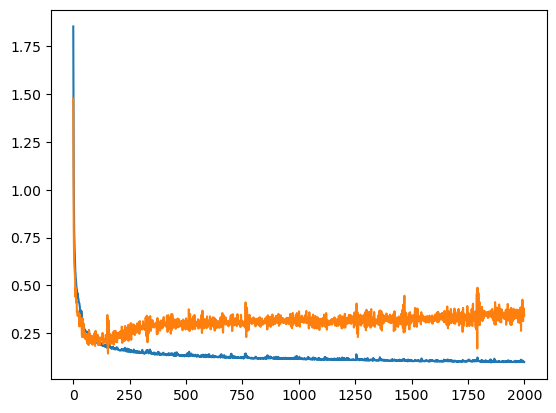

In [12]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [13]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

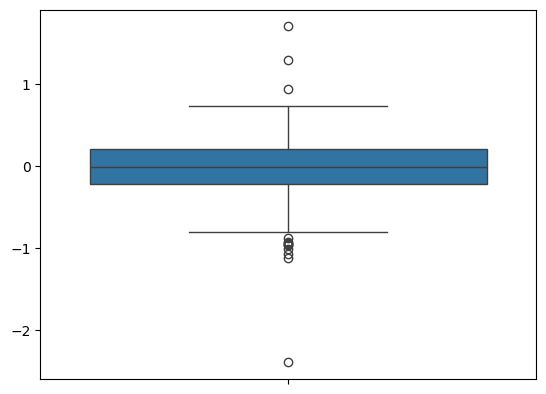

In [14]:
sns.boxplot(model1_weight_layer1)

<Axes: >

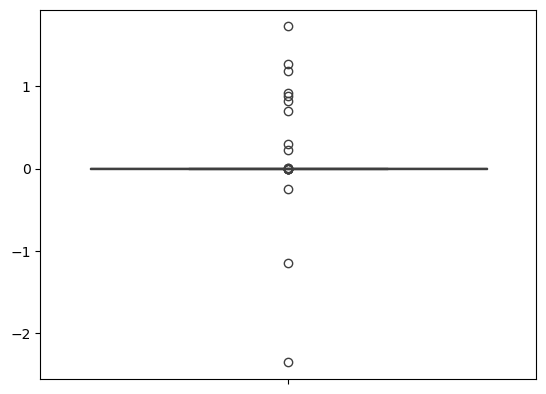

In [15]:
sns.boxplot(model2_weight_layer1)

here all the weight are aroung 0

In [16]:
model1_weight_layer1.min()

-2.4002323

In [17]:
model2_weight_layer1.min()

-2.3617437

C:\Users\himan\AppData\Local\Temp\ipykernel_17296\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\himan\AppData\Local\Temp\ipykernel_17296\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

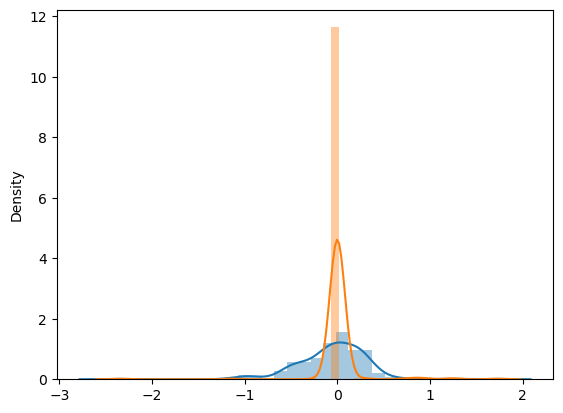

In [18]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [19]:
model1.get_weights()[0].reshape(256)

array([ 2.58244783e-01,  4.18134958e-01,  2.79415280e-01, -3.29813123e-01,
        8.93796235e-02, -1.51879251e-01, -1.74846008e-01,  4.87227039e-03,
        7.14641903e-03,  2.47457787e-01,  5.55328012e-01,  9.02789533e-02,
        1.00728206e-01, -4.09596860e-01, -4.59006935e-01, -5.37912846e-01,
       -3.05773392e-02, -4.99269277e-01,  2.48851374e-01,  2.41780534e-01,
       -6.79797158e-02, -5.51059917e-02, -3.77632260e-01, -4.60220605e-01,
       -2.67502874e-01,  3.14114630e-01,  9.53629613e-02,  8.27226788e-02,
        1.21659301e-01,  9.07774195e-02,  3.33540440e-01, -3.72015715e-01,
        2.69915283e-01,  2.84497738e-01, -5.25422812e-01,  2.64467448e-01,
        1.99604601e-01,  2.69842654e-01,  2.30072364e-01, -4.19948310e-01,
        1.82863384e-01,  2.04665661e-02, -2.19791248e-01, -1.60632014e-01,
       -5.55167019e-01, -4.73054439e-01,  7.47180730e-02, -5.80467701e-01,
       -3.92950088e-01,  1.58119723e-01,  2.50100285e-01,  2.14545280e-01,
        2.22591132e-01,  